In [1]:
import sys
sys.path.append("..")

from phoenix import synthesis, gates, utils
from phoenix import Circuit
import cirq
import numpy as np
from mitiq import ddd

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
circ = cirq.testing.random_circuit(10, 10, 0.5)
circ

┌──┐   ┌──────┐   ┌───┐       ┌──────┐           ┌──────┐
0: ────────────H───────────────────X────X────────────────────────────@────
                                   │    │                            │
1: ────────────T──────Z────────────┼────┼───────────────────────iSwap┼────
                                   │    │                       │    │
2: ───────────────────×──────────Z─┼────@───────────────────────┼────@────
                      │            │                            │
3: ───────S────Z──────┼iSwap─────×─┼────S──────────────S────────iSwap─────
                      ││         │ │
4: ─────────────@─────┼┼─────────┼─┼────Y──────────────H──────────────────
                │     ││         │ │
5: ─────────────┼─────┼iSwap─────┼─┼────T─────────────────────────────────
                │     │          │ │
6: ───Y───X────H┼─────┼──────────┼X┼──────────iSwap─────────────Z─────────
                │     │          │││          │
7: ────────────T┼─────×──────────┼@┼────H────S┼─────────────────X─────────
                │                │ │          │
8: ─────────────┼────────────────×─┼────X─────iSwap───────────────────────
                │                  │
9: ─────────────X─────S────────────@───────────────────X──────────────────
              └──┘   └──────┘   └───┘       └──────┘           └──────┘

In [3]:
circ = Circuit.from_cirq(circ)
circ_ = circ.nonlocal_structure.to_cirq()

In [4]:
synthesis.ordering.left_end_empty_layers(circ)

array([1, 5, 0, 0, 0, 0, 1, 0, 4, 0])

In [14]:
mask = ddd.insertion._get_circuit_mask(circ_)
print(mask)

[[0 0 0 0 1 1 1 1 1 1 0 0 0]
 [1 1 1 1 1 1 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 1 0 0 0 1 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 0 0]
 [1 1 1 1 1 0 0 0 0 1 1 1 1]
 [0 0 0 0 0 1 1 1 1 1 1 0 0]
 [1 1 0 0 0 0 1 0 1 0 0 0 0]
 [0 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1 1 1 1]]


In [21]:
np.argmax(mask, axis=1)

array([4, 0, 0, 5, 4, 0, 5, 0, 5, 6])

In [60]:
N = 10000
circs = []
circs_ = []
for _ in range(N):
    circ = cirq.testing.random_circuit(10, 10, 0.5)
    circ = Circuit.from_cirq(circ).nonlocal_structure
    circ_ = circ.to_cirq()
    circs.append(circ)
    circs_.append(circ_)

In [61]:
ls = []
for i in range(N):
    l = synthesis.ordering.left_end_empty_layers(circs[i])
    ls.append(l)

In [62]:
ls[:10]

[array([0, 0, 0, 0, 0, 0, 8, 1, 0, 0]),
 array([ 8,  1,  2, 12, 13,  0,  0,  0, 14,  0]),
 array([0, 7, 0, 0, 0, 0, 6, 1, 1, 0]),
 array([0, 5, 0, 0, 0, 0, 0, 4, 0, 0]),
 array([0, 0, 2, 0, 2, 0, 2, 0, 0, 1]),
 array([1, 0, 0, 0, 1, 0, 0, 0, 1, 3]),
 array([ 0, 12,  8,  8,  4, 13,  0,  8,  0,  0]),
 array([2, 0, 0, 0, 1, 0, 1, 0, 1, 0]),
 array([4, 0, 0, 0, 1, 0, 4, 0, 5, 0]),
 array([0, 0, 1, 0, 0, 0, 3, 0, 0, 0])]

In [63]:
ls1 = []
for i in range(N):
    l1 = np.argmax(ddd.insertion._get_circuit_mask(circs_[i]), axis=1)
    ls1.append(l1)

In [64]:
ls1[:10]

[array([0, 0, 0, 0, 0, 0, 8, 1, 0, 0]),
 array([ 8,  1,  2, 12, 13,  0,  0,  0,  0]),
 array([0, 0, 0, 0, 0, 6, 1, 1, 0]),
 array([0, 5, 0, 0, 0, 0, 0, 4, 0, 0]),
 array([0, 0, 0, 0, 0, 0, 1]),
 array([1, 0, 0, 0, 1, 0, 0, 0, 1, 3]),
 array([ 0, 12,  8,  8,  4,  0,  8,  0,  0]),
 array([2, 0, 0, 0, 1, 0, 1, 0, 1, 0]),
 array([4, 0, 0, 0, 1, 0, 4, 0, 0]),
 array([0, 0, 1, 0, 0, 0, 3, 0, 0, 0])]

In [66]:
for i in range(N):
    if ls[i].shape != ls1[i].shape:
        print(i)
        continue
    if not np.allclose(ls[i], ls1[i]):
        print("not equal")
        break

1
2
4
6
8
13
15
17
18
22
25
26
28
29
31
35
36
37
40
41
43
46
49
52
56
63
64
69
70
71
73
75
78
82
84
88
95
100
102
106
107
110
111
114
115
117
119
124
128
132
134
137
140
142
145
146
149
152
158
161
162
171
176
177
181
182
183
186
187
192
193
197
198
201
202
210
214
215
220
221
227
232
233
238
241
242
243
245
247
251
252
255
256
260
261
271
272
273
274
280
282
283
286
289
291
297
298
299
300
302
303
309
313
314
315
316
317
318
319
322
323
325
328
329
331
333
334
336
338
344
345
347
360
363
365
366
368
373
374
378
379
380
384
388
389
392
393
395
397
402
403
409
412
413
414
421
422
423
424
428
429
430
439
443
444
454
455
460
467
473
478
483
485
499
503
508
512
518
521
524
528
535
537
538
544
551
554
556
557
559
561
564
565
571
572
577
578
582
583
588
594
595
597
598
605
606
611
613
618
620
622
626
633
637
639
640
641
643
644
649
650
655
657
658
659
660
663
665
674
678
685
686
688
693
694
697
699
705
714
717
718
720
721
722
728
731
733
735
740
746
749
756
757
759
760
762
765
767
769
770
77

In [67]:
ls[1], ls1[1]

(array([ 8,  1,  2, 12, 13,  0,  0,  0, 14,  0]),
 array([ 8,  1,  2, 12, 13,  0,  0,  0,  0]))

In [70]:
circs[1].to_cirq()

┌──┐   ┌──┐   ┌──┐                       ┌──┐
0: ─────────────────────────────────────────────@─────────────────────────@───
                                                │                         │
1: ────────────×────────────────────────────────┼@────X───X───@───×───×───┼───
               │                                ││    │   │   │   │   │   │
2: ────────────┼──────×─────────────────────────┼┼────┼───┼───┼───┼───┼───┼───
               │      │                         ││    │   │   │   │   │   │
3: ────────────┼──────┼─────────────────────────┼┼────┼───┼───┼───×───┼───┼───
               │      │                         ││    │   │   │       │   │
4: ────────────┼──────┼─────────────────────────┼┼────┼───┼───┼───────×───@───
               │      │                         ││    │   │   │
5: ────@──────X┼─────X┼────@───@───X───X───@────┼X────@───@───X───×───×───────
       │      ││     ││    │   │   │   │   │    │                 │   │
6: ────┼X─────┼×─────┼×────┼───┼───┼───┼───┼────┼─────────────────┼───┼───X───
       ││     │      │     │   │   │   │   │    │                 │   │   │
7: ────X┼─────@──────@─────X───X───@───@───X────X─────────────────┼───×───@───
        │                                                         │
9: ─────@─────────────────────────────────────────────────────────×───────────
      └──┘   └──┘   └──┘                       └──┘

In [72]:
circs_[1]

┌──┐   ┌──┐   ┌──┐                       ┌──┐
0: ─────────────────────────────────────────────@─────────────────────────@───
                                                │                         │
1: ────────────×────────────────────────────────┼@────X───X───@───×───×───┼───
               │                                ││    │   │   │   │   │   │
2: ────────────┼──────×─────────────────────────┼┼────┼───┼───┼───┼───┼───┼───
               │      │                         ││    │   │   │   │   │   │
3: ────────────┼──────┼─────────────────────────┼┼────┼───┼───┼───×───┼───┼───
               │      │                         ││    │   │   │       │   │
4: ────────────┼──────┼─────────────────────────┼┼────┼───┼───┼───────×───@───
               │      │                         ││    │   │   │
5: ────@──────X┼─────X┼────@───@───X───X───@────┼X────@───@───X───×───×───────
       │      ││     ││    │   │   │   │   │    │                 │   │
6: ────┼X─────┼×─────┼×────┼───┼───┼───┼───┼────┼─────────────────┼───┼───X───
       ││     │      │     │   │   │   │   │    │                 │   │   │
7: ────X┼─────@──────@─────X───X───@───@───X────X─────────────────┼───×───@───
        │                                                         │
9: ─────@─────────────────────────────────────────────────────────×───────────
      └──┘   └──┘   └──┘                       └──┘

In [74]:
mask = ddd.insertion._get_circuit_mask(circs_[1])
mask

array([[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
       [0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]])

In [75]:
ls1[1]

array([ 8,  1,  2, 12, 13,  0,  0,  0,  0])

---

### common Clifford2Q

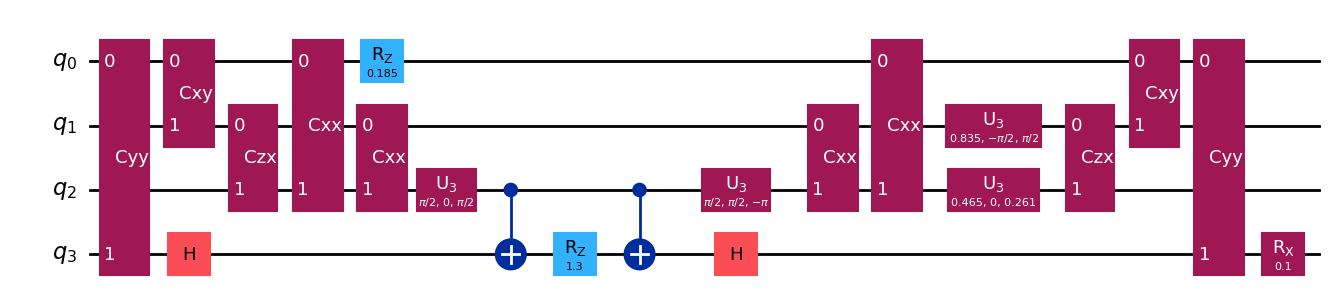

In [8]:
from phoenix import models


# paulis = ['ZYZZ', 'XZZY', 'ZYXY', 'ZIYX', 'ZXIY', 'IZYX', 'XXXY', 'XYXI', 'YIXX', 'XZYY', 'ZZIZ', 'YXXI']
paulis = ['ZYZZ', 'XZZY', 'ZYXY', 'XXXY', 'XZYY']
ham = models.HamiltonianModel(paulis, coeffs=np.random.rand(len(paulis)))
c = ham.phoenix_circuit()
# c.remove(c[0])
c.append(gates.RX(0.1).on(3))
c.to_qiskit().draw('mpl')


In [9]:
utils.passes.obtain_front_layer_from_circuit(c, predicate=lambda x: x.num_qregs > 1)

[C(Y, Y){0|3}]

In [10]:
utils.passes.obtain_front_layer(c, predicate=lambda x: x.num_qregs > 1)

[C(Y, Y){0|3}]